In [1]:
%pip install tensorflow

In [2]:
import numpy as np
from tensorflow.keras.datasets import mnist
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten

(x_train, y_train), (x_test, y_test) = mnist.load_data()

# we reduced the dataset to 10% of the original size since it takes too long to train the model.
train_size = int(0.1 * len(x_train))
test_size = int(0.1 * len(x_test))

# Randomly select 10% of the data.
np.random.seed(42)  # For reproducibility
train_indices = np.random.choice(len(x_train), train_size, replace=False)
test_indices = np.random.choice(len(x_test), test_size, replace=False)

x_train_small = x_train[train_indices]
y_train_small = y_train[train_indices]
x_test_small = x_test[test_indices]
y_test_small = y_test[test_indices]

# Preprocess the data.
x_train_small = x_train_small.astype("float32") / 255
x_test_small = x_test_small.astype("float32") / 255

# Convert labels to categorical one-hot encoding.
y_train_small = to_categorical(y_train_small, 10)
y_test_small = to_categorical(y_test_small, 10)

In [3]:
model = Sequential([
    Flatten(input_shape=(28, 28)),
    Dense(128, activation="relu"),
    Dense(10, activation="softmax")
])

c:\Users\farha\anaconda3\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [4]:
model.compile(
    optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"]
)

In [5]:
history = model.fit(
    x_train_small, y_train_small,
    epochs=10, batch_size=32
)

Epoch 1/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8202 - loss: 0.6543
Epoch 2/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9172 - loss: 0.2921
Epoch 3/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9393 - loss: 0.2139
Epoch 4/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9548 - loss: 0.1684
Epoch 5/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9637 - loss: 0.1328
Epoch 6/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9722 - loss: 0.1049
Epoch 7/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9788 - loss: 0.0833
Epoch 8/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9870 - loss: 0.0618
Epoch 9/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9895 - loss: 0.0512
Epoch 10/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9937 - loss: 0.0403


In [6]:
test_loss, test_acc = model.evaluate(x_test_small, y_test_small)
print(f"Test accuracy: {test_acc}.")

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9470 - loss: 0.1697
Test accuracy: 0.9470000267028809.


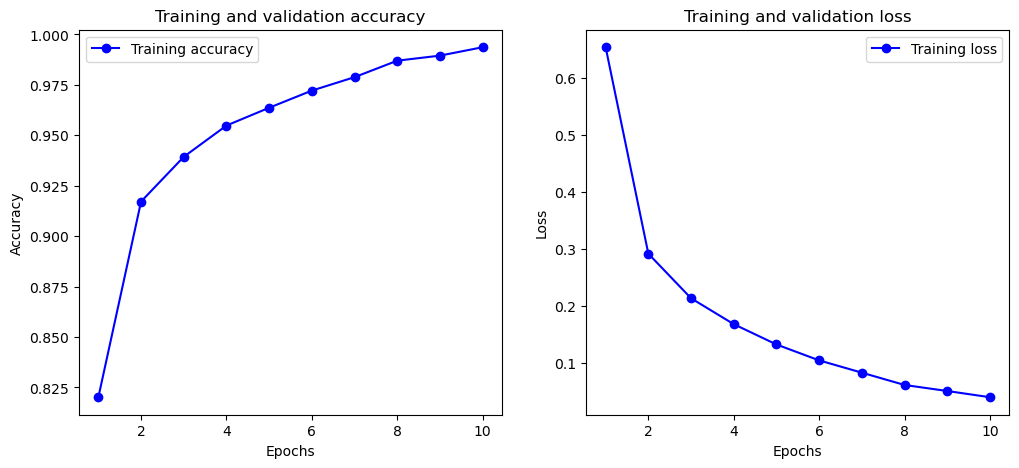

In [7]:
import matplotlib.pyplot as plt

keys = history.history.keys()

acc = history.history.get('accuracy') or history.history.get('binary_accuracy')
val_acc = history.history.get('val_accuracy') or history.history.get('val_binary_accuracy')
loss = history.history.get('loss')
val_loss = history.history.get('val_loss')

epochs = range(1, len(acc) + 1)

plt.figure(figsize=(12, 5))

# Plot accuracy
plt.subplot(1, 2, 1)
plt.plot(epochs, acc, 'bo-', label='Training accuracy')
if val_acc is not None:
    plt.plot(epochs, val_acc, 'ro-', label='Validation accuracy')
plt.title('Training and validation accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

# Plot loss
plt.subplot(1, 2, 2)
plt.plot(epochs, loss, 'bo-', label='Training loss')
if val_loss is not None:
    plt.plot(epochs, val_loss, 'ro-', label='Validation loss')
plt.title('Training and validation loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.show()

## Question 1: What is the accuracy of your neural network on the MNIST test set?

The accuracy of the neural network on the MNIST test set is 94.7%.

## Question 2: How do the training and validation curves for accuracy and loss behave over the epochs? Are there any signs of overfitting or underfitting?

The training accuracy increases steadily from around 0.82 to almost 1.00 over 10 epochs. This shows that the model is learning effectively — its performance on the training set is improving consistently. The training loss decreases sharply from around 0.65 to below 0.05. This inverse relationship with accuracy is expected, since as accuracy increases, loss should decrease. To completely check if the training is not overfitting, we would need to look at the validation curves.